 Atlas loaded - shape: (528, 320, 456), dtype: uint16
Total slices : 528
Empty slices : 2 (< 10% content)
Useful slices : 526
Mean adjacent slice correlation:  0.992
Min adjacent slice correlation:  0.000


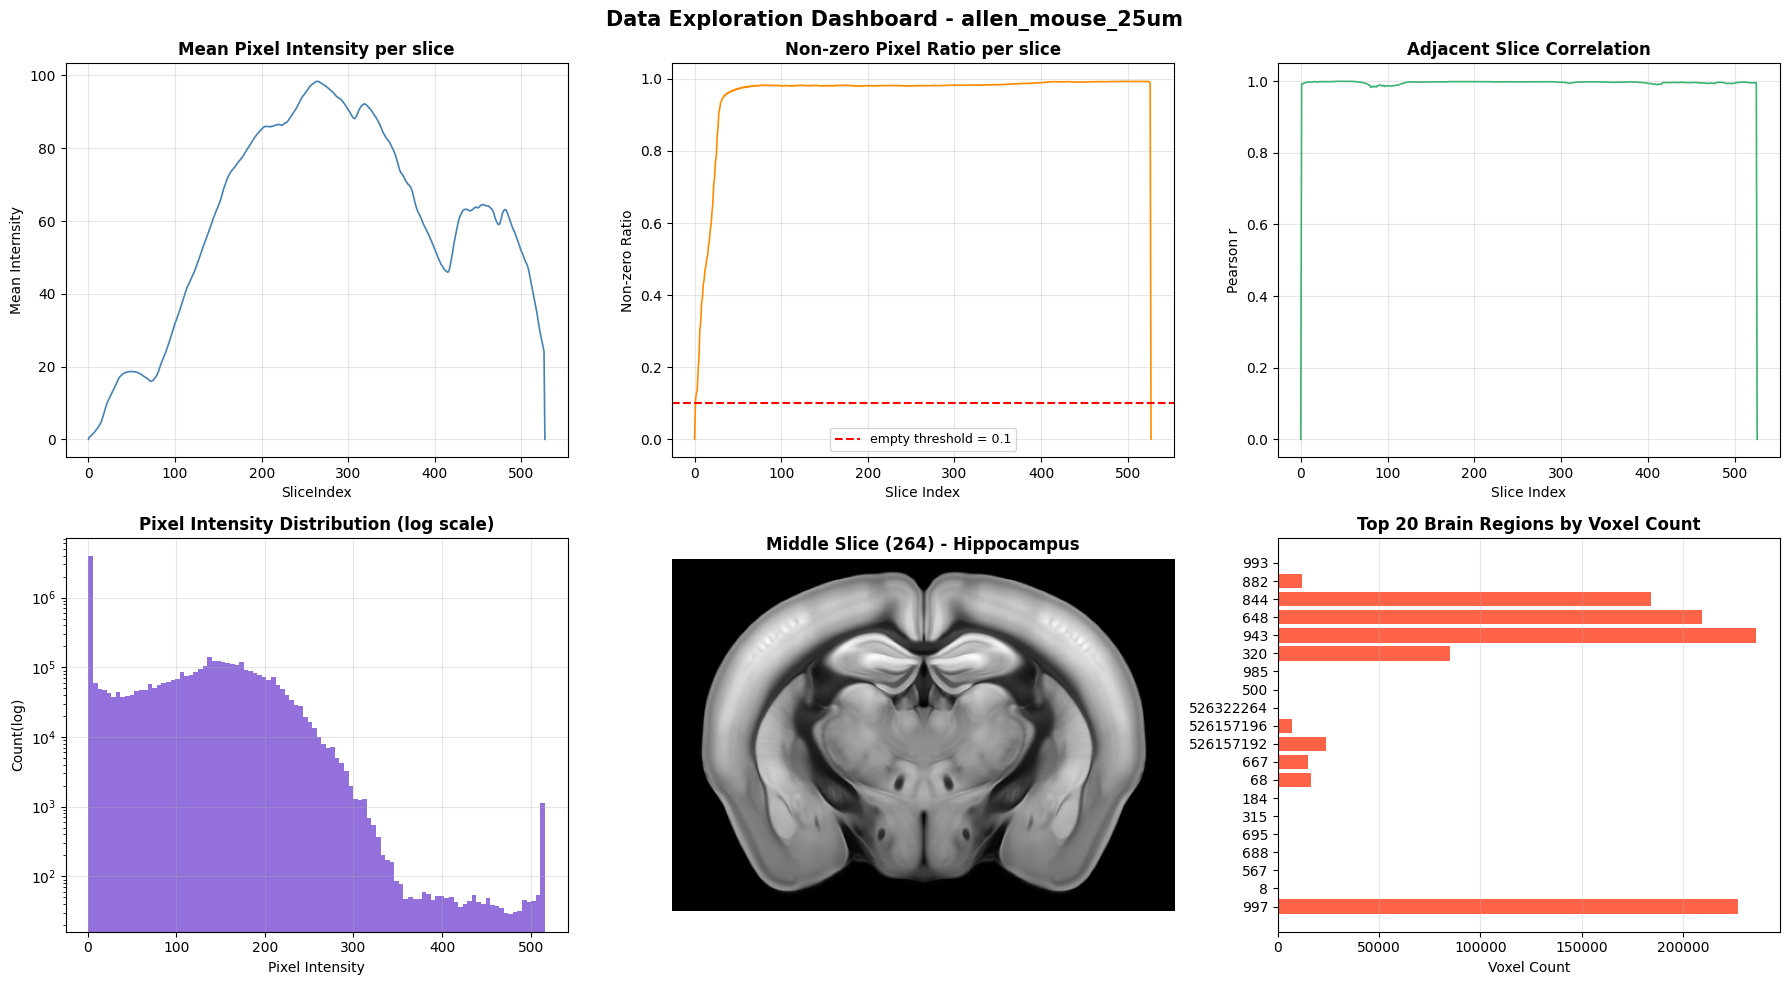

Dashboard saved to results/plot/data_explorations.png
Slice statistics saved to results/embeddings/


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from brainglobe_atlasapi import BrainGlobeAtlas
import os

atlas = BrainGlobeAtlas('allen_mouse_25um')
volume = atlas.reference
print(f" Atlas loaded - shape: {volume.shape}, dtype: {volume.dtype}")

slice_means = np.array([volume[i].mean() for i in range(volume.shape[0])])
slice_stds = np.array([volume[i].std() for i in range(volume.shape[0])])
slice_nonzero = np.array([(volume[i] > 0).mean() for i in range(volume.shape[0])])

EMPTY_THRESHOLD = 0.10
empty_mask = slice_nonzero < EMPTY_THRESHOLD
useful_mask = ~empty_mask
print(f'Total slices : {volume.shape[0]}')
print(f'Empty slices : {empty_mask.sum()} (< {EMPTY_THRESHOLD*100:.0F}% content)')
print(f'Useful slices : {useful_mask.sum()}')

correlations = []
for i in range(volume.shape[0] - 1):
    s1 = volume[i].astype(float).flatten()
    s2 = volume[i+1].astype(float).flatten()
    if np.std(s1) == 0 or np.std(s2) == 0:
        corr = 0
    else:
        corr = np.corrcoef(s1,s2)[0,1]
    correlations.append(corr)
correlations = np.array(correlations)

print(f'Mean adjacent slice correlation: {correlations.mean(): .3f}')
print(f'Min adjacent slice correlation: {correlations.min(): .3f}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Data Exploration Dashboard - allen_mouse_25um', fontsize=15,
fontweight='bold')

axes[0,0].plot (slice_means, color='steelblue', linewidth = 1.2)
axes[0,0].set_title('Mean Pixel Intensity per slice', fontweight='bold')
axes[0,0].set_xlabel('SliceIndex')
axes[0,0].set_ylabel('Mean Internsity')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(slice_nonzero, color='darkorange', linewidth=1.2)
axes[0,1].axhline(EMPTY_THRESHOLD, color='red', linestyle='--',
                 label=f'empty threshold = {EMPTY_THRESHOLD}')
axes[0,1].set_title('Non-zero Pixel Ratio per slice', fontweight='bold')
axes[0,1].set_xlabel('Slice Index')
axes[0,1].set_ylabel('Non-zero Ratio')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(correlations, color='mediumseagreen', linewidth=1.2)
axes[0,2].set_title('Adjacent Slice Correlation', fontweight='bold')
axes[0,2].set_xlabel('Slice Index')
axes[0,2].set_ylabel('Pearson r')
axes[0,2].grid(True, alpha=0.3)

sample_pixels = volume[::10].flatten()
axes[1,0].hist(sample_pixels[sample_pixels > 0], bins=100,
              color='mediumpurple', log=True)
axes[1,0].set_title('Pixel Intensity Distribution (log scale)', fontweight='bold')
axes[1,0].set_xlabel('Pixel Intensity')
axes[1,0].set_ylabel('Count(log)')
axes[1,0].grid(True, alpha=0.3)

mid = volume.shape[0] // 2
axes[1,1].imshow(volume[264], cmap='grey')
axes[1,1].set_title(f'Middle Slice ({mid}) - Hippocampus', fontweight='bold')
axes[1,1].axis('off')

structure_keys = list(atlas.structures.keys())[:20]
region_counts = np.array([(atlas.annotation == r).sum() for r in structure_keys])
region_labels = [str(r) for r in structure_keys]

axes[1,2].barh(range(20), region_counts, color = 'tomato')
axes[1,2].set_yticks(range(20))
axes[1,2].set_yticklabels(region_labels, fontweight=8)
axes[1,2].set_title('Top 20 Brain Regions by Voxel Count', fontweight='bold')
axes[1,2].set_xlabel('Voxel Count')
axes[1,2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
os.makedirs('results/plots',exist_ok=True)
os.makedirs('results/embeddings',exist_ok=True)
np.save('results/embeddings/slice_means.npy', slice_means)

plt.savefig('results/plots/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to results/plot/data_explorations.png")

np.save('results/embeddings/slice_means.npy', slice_means)
np.save('results/embeddings/slice_nonzero.npy', slice_nonzero)
np.save('results/embeddings/correlations.npy', correlations)
np.save('results/embeddings/empty_mask.npy', empty_mask)
print("Slice statistics saved to results/embeddings/")

In [1]:
import sys
import os

project_src = os.path.join(os.getcwd(), 'src')
sys.path = [p for p in sys.path if 'Nity Hiry\\src' not in p]
sys.path.insert(0,project_src)

for mod in list(sys.modules.keys()):
    if 'preprocessing' in mod or 'config' in mod:
        del sys.modules[mod]

from preprocessing import BrainSlicePreprocessor, PreprocessConfig

preprocessor = BrainSlicePreprocessor()

print("BrainSliceProcessor loaded Successfully!")
print(f" IMG_SIZE : {preprocessor.cfg.img_size}")
print(f" CLAHE_CLIP : {preprocessor.cfg.clahe_clip}")
print(f" CLAHE_GRID : {preprocessor.cfg.clahe_grid}")
print(f" denoise_h : {preprocessor.cfg.denoise_h}")
print(f" min_content : {preprocessor.cfg.min_content}")

BrainSliceProcessor loaded Successfully!
 IMG_SIZE : 224
 CLAHE_CLIP : 2.0
 CLAHE_GRID : (8, 8)
 denoise_h : 10.0
 min_content : 0.05


In [2]:
import numpy as np
import tifffile
import os
import sys
sys.path.insert(0, 'src')

from preprocessing import BrainSlicePreprocessor
from brainglobe_atlasapi import BrainGlobeAtlas

os.makedirs('data/raw_images', exist_ok = True)

atlas = BrainGlobeAtlas('allen_mouse_25um')

for i,idx in enumerate([100, 150, 200, 264, 300]):
    tifffile.imwrite(
        f'data/raw_images/slice_{idx:04}.tif',
        atlas.reference[idx]
    )

print("Sample TIFF slices saved to data/raw_images/")

stats = preprocessor.process_directory(
    input_dir = 'data/raw_images',
    output_dir = 'data/processed_images'
)

print(f"\n Preprocessing complete!")
print(f" Total files : {stats['total']}")
print(f" Accepted : {stats['accepted']}")
print(f" Rejected : {stats['rejected']}")
print(f" Rejected rate: {stats['rejection_rate']*100:.1f}%")

Sample TIFF slices saved to data/raw_images/


Preprocessing: 100%|█████████████████████████| 5/5 [00:01<00:00,  3.04it/s]
INFO:preprocessing:Preprocessing done. Accepted: 5, Rejected: 0



 Preprocessing complete!
 Total files : 5
 Accepted : 5
 Rejected : 0
 Rejected rate: 0.0%


In [5]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

processed = np.load('data/processed_images/slice_0264.npy')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Preprocessing Verification', fontsize = 13, fontweight='bold')

axes[0].imshow(atlas.reference[264], cmap='gray')
axes[0].set_title('Original (uint16)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(processed, cmap='gray')
axes[1].set_title(f'processed (float32) - shape: {processed.shape}', fontweight = 'bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('results/plots/preprocessing_check.png', dpi = 150)
plt.close()
print('Plot saved to results/plots/preprocessing_check.png')

Plot saved to results/plots/preprocessing_check.png
